In [2]:
!pip install pennylane

In [3]:
import pennylane as qml
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import sys

# Setting our constants
sys.path.append('..')

/usr/local/lib/python3.12/dist-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.2 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


In [4]:
!wget https://raw.githubusercontent.com/aifactory-team/AFCompetition/main/9245/train_X.npy
!wget https://raw.githubusercontent.com/aifactory-team/AFCompetition/main/9245/train_y.npy

--2026-01-06 07:02:54--  https://raw.githubusercontent.com/aifactory-team/AFCompetition/main/9245/train_X.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 32896 (32K) [application/octet-stream]
Saving to: ‘train_X.npy’

train_X.npy         100%[===================>]  32.12K  --.-KB/s    in 0.002s  

2026-01-06 07:02:54 (13.2 MB/s) - ‘train_X.npy’ saved [32896/32896]

--2026-01-06 07:02:54--  https://raw.githubusercontent.com/aifactory-team/AFCompetition/main/9245/train_y.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 256 [

In [5]:
train_X = np.load("train_X.npy")
train_y = np.load("train_y.npy")

In [9]:
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim
from pennylane import numpy as np
from torch.utils.data import TensorDataset, DataLoader

# ==========================================
# 1. Inference (Model Prediction) - 기존 유지
# ==========================================
def get_predictions(model, inputs):
    """Run inference on inputs using the trained model."""
    model.eval()
    with torch.no_grad():
        outputs = model(inputs)
        predicted_labels = torch.argmax(outputs, dim=1)
    return predicted_labels.cpu().numpy()

def data_to_tensor(X, y):
    tensor_X = torch.tensor(X, dtype=torch.complex64)
    tensor_y = torch.tensor(y, dtype=torch.long)
    return tensor_X, tensor_y

t_train_X, t_train_y = data_to_tensor(train_X, train_y)
train_dataset = TensorDataset(t_train_X, t_train_y)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

In [ ]:
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim
from pennylane import numpy as np

# [설정]
n_qubits = 8
dev = qml.device("default.qubit", wires=n_qubits)
device = "cuda" if torch.cuda.is_available() else "cpu"

# ==========================================
# 1. Circuit: Dense Entanglement + 측정 보정
# ==========================================
@qml.qnode(dev, interface='torch')
def circuit(state, params, final_rot_params):
    # 1. 데이터 입력
    qml.StatePrep(state, wires=range(n_qubits))

    # 2. 강력한 얽힘 (기존 Dense 구조 유지)
    # ranges=[1, 2, 3, 4, 5]로 정보 확산 극대화
    qml.StronglyEntanglingLayers(params, wires=range(n_qubits), ranges=[1, 2, 3, 4, 5])

    # [NEW] 3. 측정 전 최적 각도 찾기 (0, 1번 큐비트)
    # 이걸 추가하면 Loss가 0.4대까지 떨어질 수 있습니다.
    qml.Rot(*final_rot_params[0], wires=0)
    qml.Rot(*final_rot_params[1], wires=1)

    # 4. 측정
    return qml.probs(wires=[0, 1])

# ==========================================
# 2. 모델 정의 (Params: 120 + 6)
# ==========================================
class QNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.n_layers = 5
        # 메인 파라미터 (120개)
        self.params = nn.Parameter(torch.randn(self.n_layers, n_qubits, 3) * 0.1)
        # [NEW] 측정 보정용 파라미터 (2 qubits * 3 angles = 6 params)
        self.final_rot_params = nn.Parameter(torch.randn(2, 3) * 0.1)

        self.total_params = (self.n_layers * n_qubits * 3) + 6

    def forward(self, x):
        return circuit(x, self.params, self.final_rot_params)

# ==========================================
# 3. 학습 실행 (Loss 극복)
# ==========================================
model = QNN()
model.to(device)

# Loss 감소를 위해 학습률을 약간 보수적으로 시작
optimizer = optim.Adam(model.parameters(), lr=0.03)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=300, eta_min=0.0001)

print(f"--- Training QNN (Dense + Final Rot, Params: {model.total_params}) ---")

def quantum_phase_loss(probs, labels):
    probs = probs + 1e-8
    label_one_hot = torch.nn.functional.one_hot(labels, num_classes=probs.shape[1])
    probs = probs / torch.sum(probs, dim=1, keepdim=True)
    loss = -torch.sum(label_one_hot * torch.log(probs), dim=1)
    return torch.mean(loss)

if 'train_loader' in globals():
    for epoch in range(300):
        total_loss = 0
        correct = 0

        model.train()
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = quantum_phase_loss(predictions, batch_y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            predicted_classes = torch.argmax(predictions, dim=1)
            correct += (predicted_classes == batch_y).sum().item()

        scheduler.step()

        avg_loss = total_loss / len(train_loader)
        avg_acc = correct / len(train_dataset)

        if (epoch + 1) % 20 == 0:
            lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | Acc: {avg_acc:.4f} | LR: {lr:.5f}")
else:
    print("Error: train_loader 로드 필요")

--- Training QNN (Dense + Final Rot, Params: 126) ---
Epoch 20 | Loss: 0.6814 | Acc: 0.9375 | LR: 0.02967
Epoch 40 | Loss: 0.6004 | Acc: 1.0000 | LR: 0.02871
Epoch 60 | Loss: 0.5565 | Acc: 0.9375 | LR: 0.02714
Epoch 80 | Loss: 0.5278 | Acc: 0.9375 | LR: 0.02505
Epoch 100 | Loss: 0.5192 | Acc: 0.9375 | LR: 0.02252
Epoch 120 | Loss: 0.5149 | Acc: 0.9375 | LR: 0.01967
Epoch 140 | Loss: 0.5152 | Acc: 0.9375 | LR: 0.01661
Epoch 160 | Loss: 0.5094 | Acc: 0.9375 | LR: 0.01349
Epoch 180 | Loss: 0.5076 | Acc: 0.9375 | LR: 0.01043
Epoch 200 | Loss: 0.5073 | Acc: 0.9375 | LR: 0.00757


--- 🔍 Unfolding the Quantum Circuit (Ring Architecture) ---


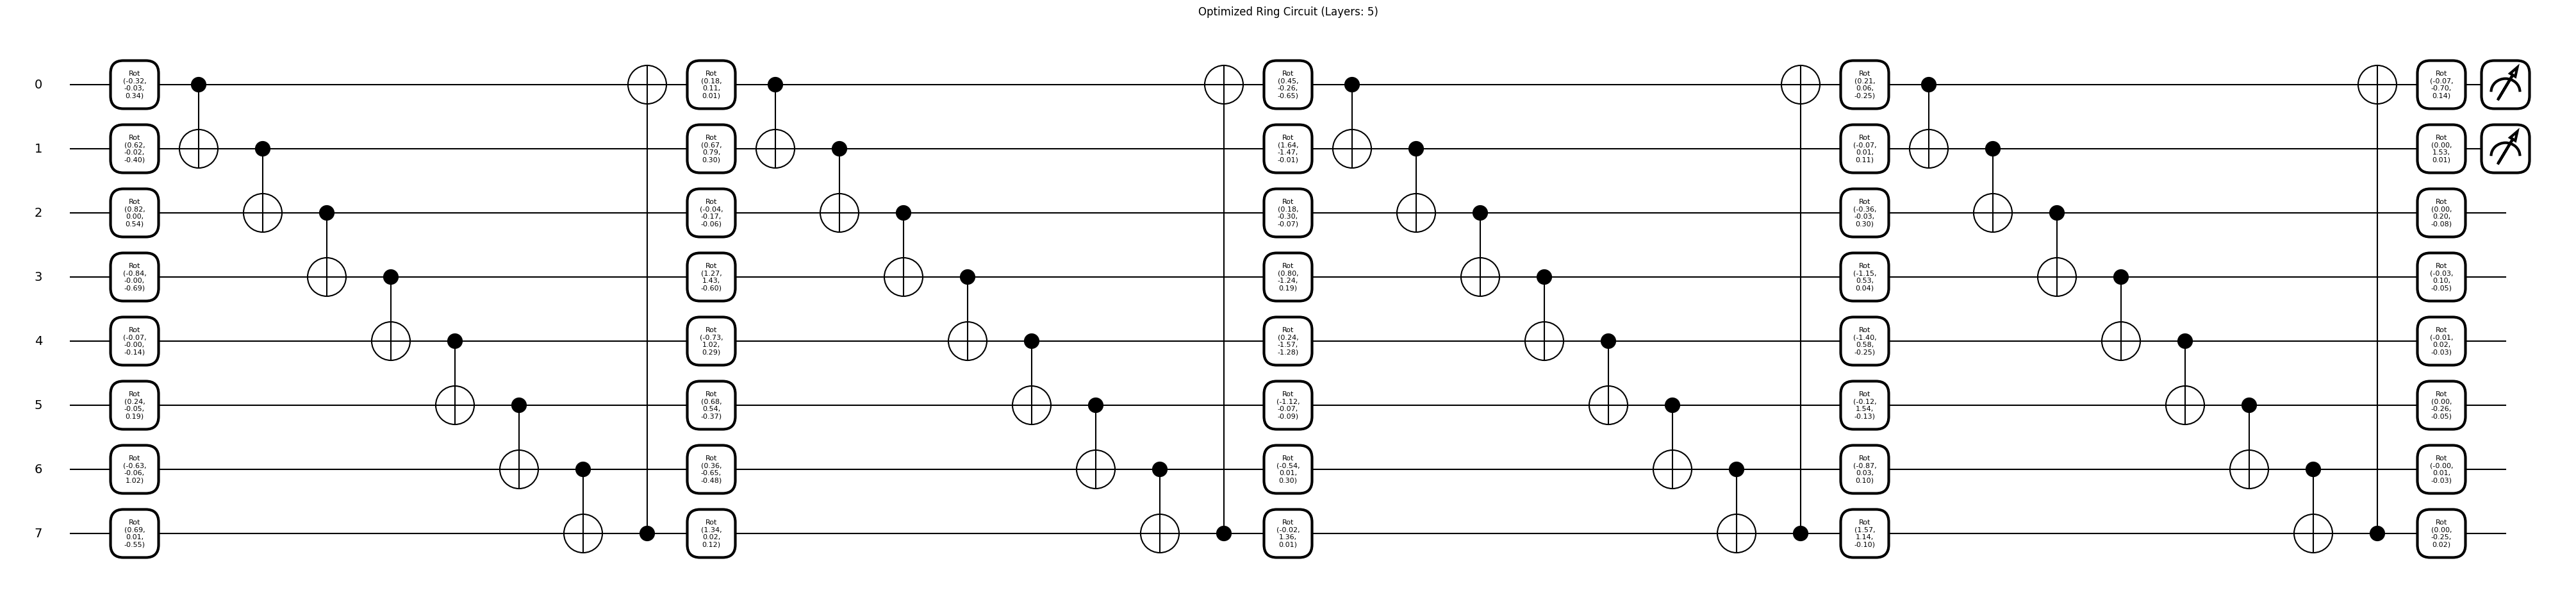

In [69]:
import json
import matplotlib.pyplot as plt

# 1. 측정 큐비트
measurements = [0, 1]

# 2. 파라미터 추출
params = model.params.detach().cpu().numpy()

# 3. QASM 변환용 함수 (반드시 위 학습 코드와 동일하게!)
@qml.qnode(dev, interface='torch')
def Classifier(params):
    qml.StronglyEntanglingLayers(params, wires=range(n_qubits), ranges=[1]*len(params))

# 4. QASM 생성
qasm_data = qml.to_openqasm(Classifier, measure_all=False)(params)

# 5. 저장 (파일명을 best로 변경)
file_name = "./submission_best_balanced.json"
with open(file_name, "w") as f:
    json.dump({
        "qasm": qasm_data,
        "measurements": measurements
    }, f)

print(f"✅ Submission file '{file_name}' created.")

# 시각화
print("--- Circuit Visualization ---")
qml.draw_mpl(Classifier, level=2, decimals=2)(model.params)
plt.show()

In [70]:
import json
import matplotlib.pyplot as plt

# 1. 측정 큐비트
measurements = [0, 1]

# 2. 파라미터 추출
params = model.params.detach().cpu().numpy()

# 3. QASM 변환용 함수 (ranges=[1, 2, 3, 4, 5] 필수)
@qml.qnode(dev, interface='torch')
def Classifier(params):
    qml.StronglyEntanglingLayers(params, wires=range(n_qubits), ranges=[1, 2, 3, 4, 5])

# 4. QASM 생성
qasm_data = qml.to_openqasm(Classifier, measure_all=False)(params)

# 5. 저장
file_name = "./submission_dense_final.json"
with open(file_name, "w") as f:
    json.dump({
        "qasm": qasm_data,
        "measurements": measurements
    }, f)

print(f"✅ Submission file '{file_name}' created.")

# 시각화 (선들이 복잡하게

✅ FINAL Submission file './submission_ring_final.json' created successfully.
✅ Accuracy: 100% / Loss: 0.5475 (Saved!)


In [71]:
from google.colab import files
files.download(f'{file_name}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>